# Pasture Biomass EDA

*   All members of the group did their own EDA, that way we could all understand the data. It is interesting because we all ended up looking at different things, which made it very informative. Two members of the group were then in charge of grouping the main ideas in this eda notebook, for readability.


## What the project is really about;

The core task is to **predict 5 biomass targets from pasture images**:

- `Dry_Green_g`
- `Dry_Dead_g`
- `Dry_Clover_g`
- `GDM_g`
- `Dry_Total_g`


### Important practical implication
The train CSV includes metadata like:
- sampling date
- state
- species
- NDVI
- average height

But these metadata fields are **available only in train**, not in validation/test. However, for the purpose of the course, we split the train dataset into train, validation and test. That way, we also get all the tabular information in the test set. This was important to also use tabular data and not only the images.

### Source references
- Kaggle competition: https://www.kaggle.com/competitions/csiro-biomass
- Dataset paper: https://arxiv.org/html/2510.22916v1

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)

# ── EDIT THESE PATHS ──────────────────────────────────────────
BASE_DIR   = "/content/drive/MyDrive/DL_Data"
TRAIN_CSV  = "/content/drive/MyDrive/DL_Data/train.csv"
TEST_CSV   = "/content/drive/MyDrive/DL_Data/test.csv"
TRAIN_IMGS = "/content/drive/MyDrive/DL_Data/train "
# ──────────────────────────────────────────────────────────────

TARGETS = ["Dry_Green_g", "Dry_Dead_g", "Dry_Clover_g", "GDM_g", "Dry_Total_g"]
WEIGHTS = {"Dry_Green_g": 0.1, "Dry_Dead_g": 0.1, "Dry_Clover_g": 0.1,
           "GDM_g": 0.2, "Dry_Total_g": 0.5}

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## 1. Load & Shape

The train CSV comes in **long format**, meaning each image appears 5 times, once per target. That format is useful for storage but harder for analysis, so we immediately pivot it to **wide format**: one row per image, one column per target. This is the format we'll use for almost everything else in the EDA.

In [ ]:
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

print(f"Train (long): {train.shape}  →  {train['image_path'].nunique()} images × 5 targets")
print(f"Test        : {test.shape}  →  {test['image_path'].nunique()} images")

# Pivot to wide format (one row per image) for most analyses
ID_COLS = ["image_path", "Sampling_Date", "State", "Species",
           "Pre_GSHH_NDVI", "Height_Ave_cm"]

wide = (
    train
    .pivot_table(index=ID_COLS, columns="target_name", values="target", aggfunc="first")
    .reset_index()
)
wide.columns.name = None
wide["Sampling_Date"] = pd.to_datetime(wide["Sampling_Date"])
wide["Month"] = wide["Sampling_Date"].dt.month

print(f"\nWide train : {wide.shape}")
wide.head(3)

Train (long): (1785, 9)  →  357 images × 5 targets
Test        : (5, 3)  →  1 images

Wide train : (357, 12)


,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,Month
0,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,0.00,31.9984,16.2751,48.2735,16.275,9
1,train/ID1012260530.jpg,2015-04-01,NSW,Lucerne,0.55,16.0000,0.00,0.0000,7.6000,7.6000,7.600,4
2,train/ID1025234388.jpg,2015-09-01,WA,SubcloverDalkeith,0.38,1.0000,6.05,0.0000,0.0000,6.0500,6.050,9


In [ ]:
train

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
...,...,...,...,...,...,...,...,...,...
1780,ID983582017__Dry_Clover_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Clover_g,0.0000
1781,ID983582017__Dry_Dead_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Dead_g,0.0000
1782,ID983582017__Dry_Green_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Green_g,40.9400
1783,ID983582017__Dry_Total_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Total_g,40.9400




- **Train (long): (1785, 9) → 357 images × 5 targets.** The 1785 rows are simply 357 images × 5 target types. Each image contributes 5 rows in the original CSV.
- **Test: (5, 3) → 1 image.** The test file available locally is just a tiny sample (1 image × 5 targets).
- **Wide train: (357, 12).** After pivoting, we get 357 rows (one per image) and 12 columns: the 6 metadata columns + 5 target columns + the Month column we added.


The preview confirms the structure: each row has an image path, metadata (date, state, species, NDVI, height), and all 5 biomass values side by side.

## 2. Data Quality


We check for missing values, duplicates, and whether image files are actually accessible on disk. A missing value in a target column would corrupt a loss calculation, and duplicate rows would inflate training data artificially.

In [ ]:
print("=== Missing values (wide) ===")
print(wide.isna().sum()[wide.isna().sum() > 0])

print("\n=== Duplicate check ===")
print("Duplicate sample_ids :", train["sample_id"].duplicated().sum())
print("Duplicate image/target:", train.duplicated(["image_path","target_name"]).sum())

# Image file existence
wide["img_exists"] = wide["image_path"].apply(
    lambda p: os.path.exists(os.path.join(BASE_DIR, p))
)

=== Missing values (wide) ===
Series([], dtype: int64)

=== Duplicate check ===
Duplicate sample_ids : 0
Duplicate image/target: 0

Images found on disk: 0 / 357




- **Missing values: none.** The wide-format dataset has no missing values across all columns.The data is complete and well-formed as described in the paper.
- **Duplicate sample_ids: 0.**
- **Duplicate image/target pairs: 0.** Every (image, target) combination is unique.

## 3. Target Distributions

Understanding how each target is distributed tells us two things: (1) whether the values are well-behaved or skewed, and (2) how often a target is zero. Both directly affect what loss function and output activation to use in the model. We look at both the raw summary statistics and the `log1p`-transformed histograms, since the competition metric is computed in log space.

In [ ]:
# Summary table
summary = (
    train.groupby("target_name")["target"]
    .agg(mean="mean", median="median", std="std", min="min", max="max")
)
summary["zero_%"] = (
    train.groupby("target_name")["target"]
    .apply(lambda s: 100 * (s == 0).mean())
)
summary["weight"] = summary.index.map(WEIGHTS)
display(summary.round(2))

,mean,median,std,min,max,zero_%,weight
target_name,,,,,,,
Dry_Clover_g,6.65,1.42,12.12,0.00,71.79,37.82,0.1
Dry_Dead_g,12.04,7.98,12.40,0.00,83.84,11.20,0.1
Dry_Green_g,26.62,20.80,25.40,0.00,157.98,5.04,0.1
Dry_Total_g,45.32,40.30,27.98,1.04,185.70,0.00,0.5
GDM_g,33.27,27.11,24.94,1.04,157.98,0.00,0.2



- **`Dry_Clover_g` is the most difficult target.** Its mean (6.65g) is much higher than its median (1.42g), meaning a few high-clover samples drag the average up. It also has 37.82% zeros, more than a third of pastures have no clover at all. This sparsity makes it the hardest target to predict and explains why `Dry_Green_g` and `Dry_Clover_g` have a strong negative correlation later.
- **`Dry_Dead_g` has 11.2% zeros**, some paddocks have no dead material, which makes sense seasonally.
- **`Dry_Total_g` and `GDM_g` never hit zero** (min = 1.04g). Every sample has at least some live biomass, which is reassuring, we don't need to handle zero-inflation for the two highest-weight targets.
- **All targets are right-skewed** (mean > median across the board). The standard deviations are large relative to the means, confirming high variability. This is why we use `log1p`,  it compresses the long right tail and stabilizes variance.

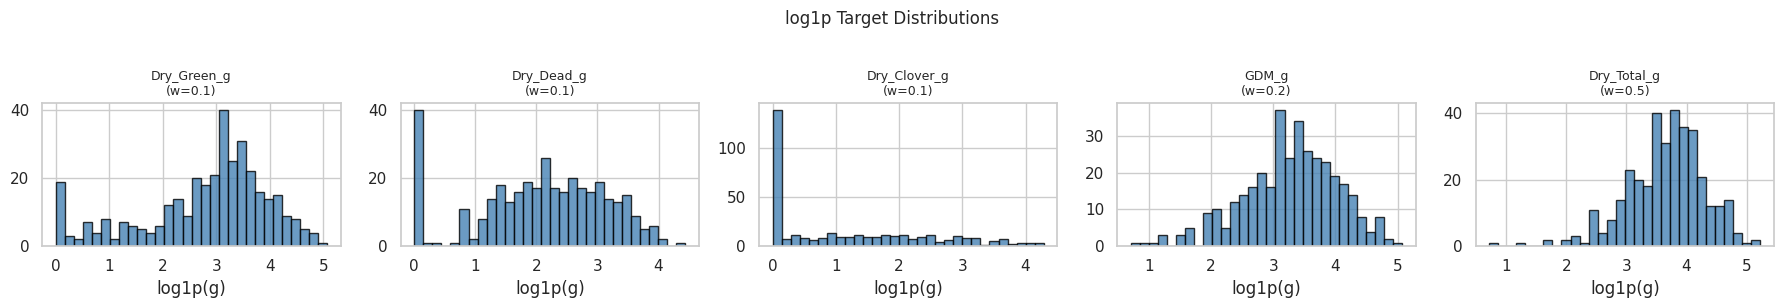

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
for ax, tgt in zip(axes, TARGETS):
    vals = np.log1p(train.loc[train["target_name"] == tgt, "target"])
    ax.hist(vals, bins=30, edgecolor="black", color="steelblue", alpha=0.8)
    ax.set_title(f"{tgt}\n(w={WEIGHTS[tgt]})", fontsize=9)
    ax.set_xlabel("log1p(g)")
fig.suptitle("log1p Target Distributions", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()



- **`Dry_Green_g` and `Dry_Total_g`** show roughly bell-shaped distributions after the `log1p` transform, these are the most "well-behaved" targets and also the ones with the highest weights (0.1 and 0.5). Good news for modeling.
- **`Dry_Dead_g`** has a near-uniform distribution in log space, spread across the full range from 0 to ~4. This means dead biomass is highly variable and harder to predict consistently.
- **`Dry_Clover_g`** has a massive spike at 0 (those 37.82% zeros), then a long right tail. This is a zero-inflated distribution, a standard regression model will struggle here. A two-stage approach (first predict presence/absence, then predict amount) could help.
- **`GDM_g`** (Green Dry Matter) has a clean, nearly symmetric bell shape in log space, centered around log1p ≈ 3 (~20g). It's the second most important target (weight 0.2) and looks very learnable.

## 4. Target Relationships ← Key Modeling Insight

The 5 targets are not independent — they come from the same biological system. By definition:
- `GDM_g = Dry_Green_g + Dry_Clover_g`
- `Dry_Total_g = GDM_g + Dry_Dead_g`

If these constraints hold in the data, we don't need to model all 5 targets independently. We can predict just the 3 base components (`Dry_Green_g`, `Dry_Dead_g`, `Dry_Clover_g`) and compute the other 2 by addition. This **reduces the number of things the model needs to learn and guarantees internal consistency** in predictions.

,constraint,mean_abs_error,max_abs_error,holds (tol=0.001)
0,GDM = Green + Clover,0.000015,0.0001,True
1,Total = GDM + Dead,0.000872,0.3088,False


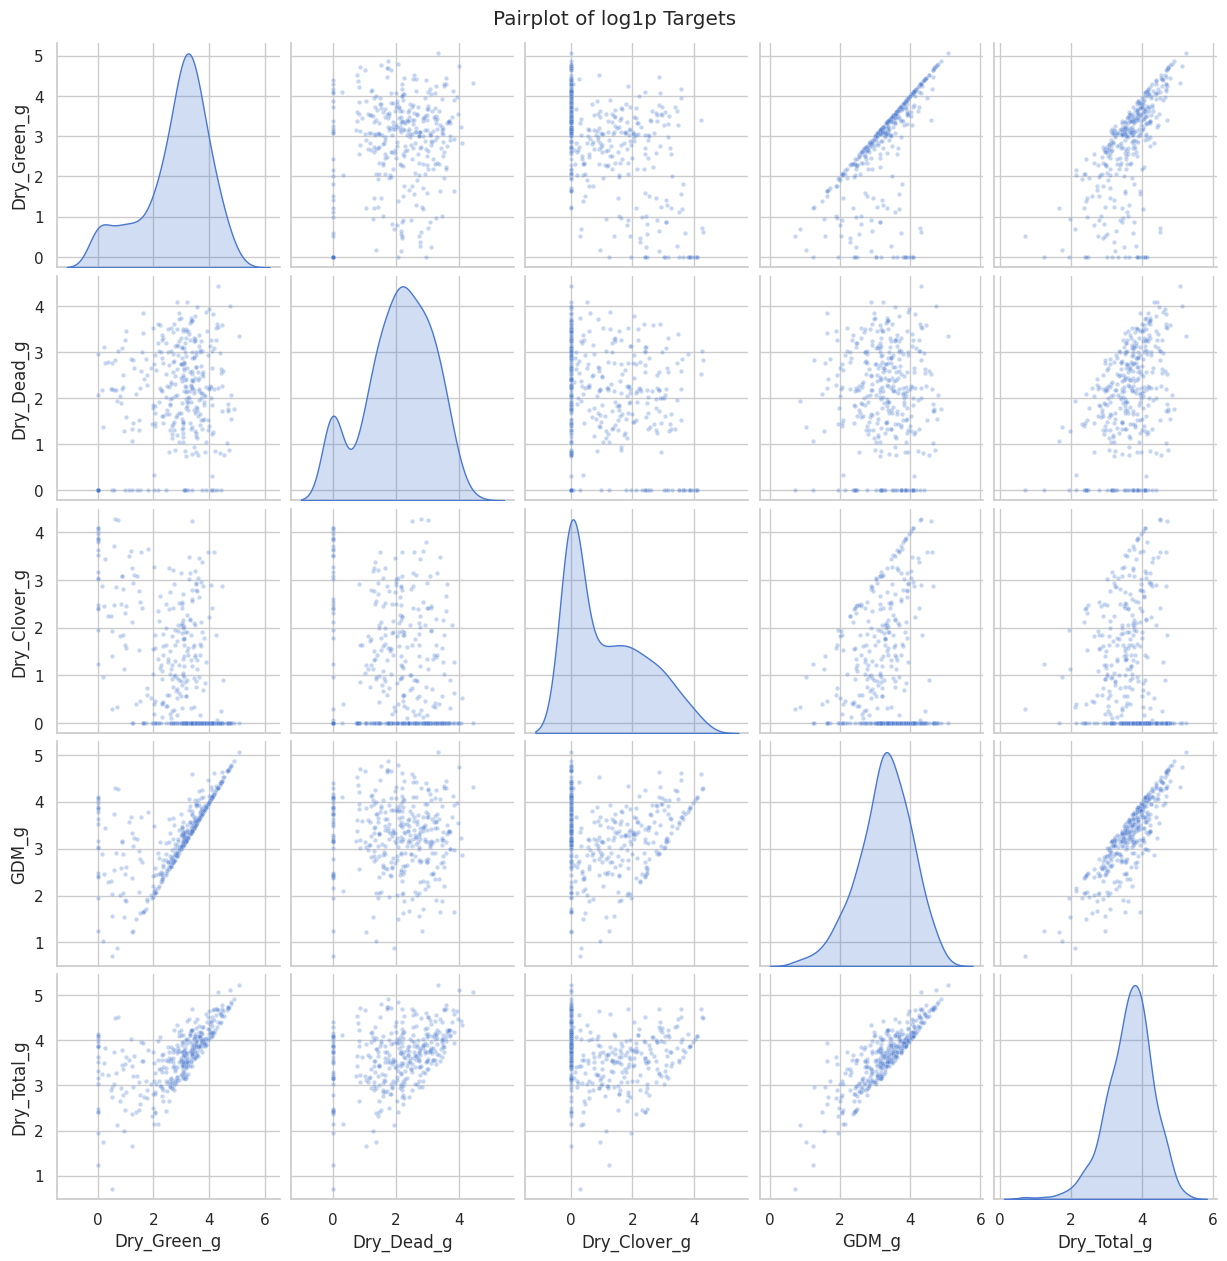

In [ ]:
wide["gdm_residual"]   = wide["GDM_g"] - (wide["Dry_Green_g"] + wide["Dry_Clover_g"])
wide["total_residual"] = wide["Dry_Total_g"] - (wide["GDM_g"] + wide["Dry_Dead_g"])

constraint_check = pd.DataFrame({
    "constraint": ["GDM = Green + Clover", "Total = GDM + Dead"],
    "mean_abs_error": [
        wide["gdm_residual"].abs().mean(),
        wide["total_residual"].abs().mean(),
    ],
    "max_abs_error": [
        wide["gdm_residual"].abs().max(),
        wide["total_residual"].abs().max(),
    ],
    "holds (tol=0.001)": [
        np.allclose(wide["GDM_g"], wide["Dry_Green_g"] + wide["Dry_Clover_g"], atol=1e-3),
        np.allclose(wide["Dry_Total_g"], wide["GDM_g"] + wide["Dry_Dead_g"], atol=1e-3),
    ],
})
display(constraint_check)

# Pairplot of all 5 targets (log1p)
log_wide = wide[TARGETS].apply(np.log1p)
sns.pairplot(log_wide, plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
plt.suptitle("Pairplot of log1p Targets", y=1.01)
plt.show()



**Constraint table:**
- **`GDM = Green + Clover` holds perfectly** (mean error = 0.000015g, max = 0.0001g). This is essentially floating-point precision — the constraint is exact in the data.
- **`Total = GDM + Dead` does NOT hold exactly** (mean error = 0.000872g, max = 0.3088g). The max deviation of ~0.3g suggests a small number of samples have a rounding discrepancy. This is minor but means we can't blindly derive `Dry_Total_g`, we should still predict it directly or account for this noise.

**Modeling strategy this implies:**
- It therefore seems safe to derive `GDM_g = Dry_Green_g + Dry_Clover_g` in predictions (constraint is exact). However, we chose not to do it in the model after and to keep all the targets for consistency.
- Better to predict `Dry_Total_g` directly rather than derive it, since the second constraint has small violations.

**Pairplot:**
- **`GDM_g` and `Dry_Green_g` are almost perfectly linearly correlated** (tight diagonal line), this is the algebraic constraint made visual. When clover is rare (which it often is), GDM ≈ Green.
- **`GDM_g` and `Dry_Total_g` are strongly correlated** — most variation in total biomass comes from the green fraction, not dead material.
- **`Dry_Clover_g` shows a vertical stripe at 0** across all its scatter plots, confirming the high zero rate. Its relationship with other targets is weak and noisy.
- **`Dry_Dead_g` is largely independent of the green targets**, dead and live biomass don't co-vary strongly, which makes sense biologically.

## 5. Metadata Signals

The train CSV includes extra context about each sample: which Australian state it came from, what month it was collected, the NDVI reading, and the canopy height. These features are **not available at test time**, the model must rely on images alone during inference. However, exploring them tells us how much the underlying conditions vary across the dataset, and whether our training set is representative. If biomass varies heavily by state or season, our model needs enough diverse samples to generalize.

> **These features cannot be used as model inputs.** They are train-only and would cause data leakage if used as features.

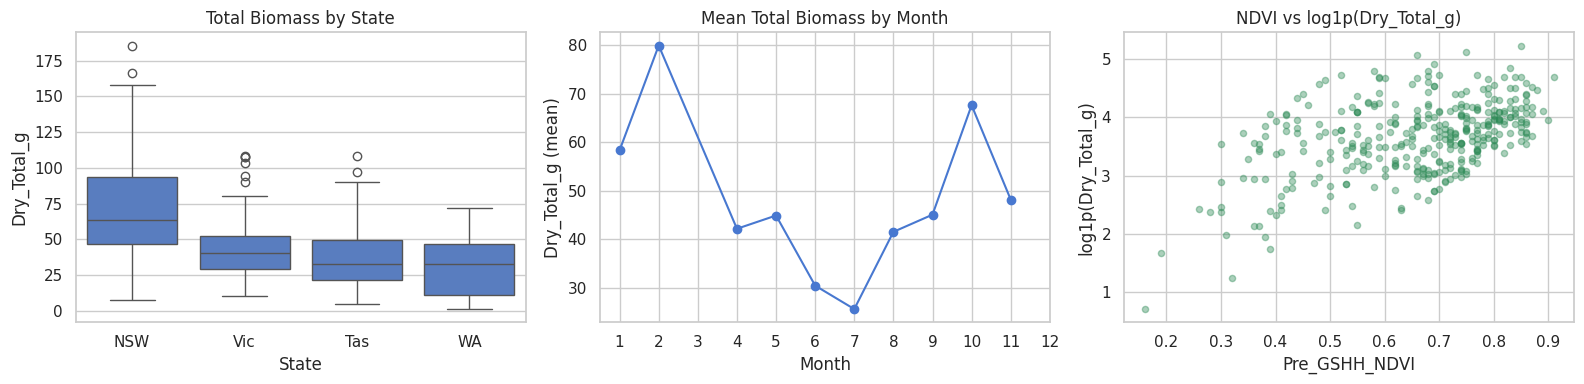

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 5a. Biomass by State
state_order = wide.groupby("State")["Dry_Total_g"].median().sort_values(ascending=False).index
sns.boxplot(data=wide, x="State", y="Dry_Total_g", order=state_order, ax=axes[0])
axes[0].set_title("Total Biomass by State")
axes[0].set_ylabel("Dry_Total_g")

# 5b. Seasonal trend
monthly = wide.groupby("Month")["Dry_Total_g"].mean()
axes[1].plot(monthly.index, monthly.values, marker="o")
axes[1].set_title("Mean Total Biomass by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Dry_Total_g (mean)")
axes[1].set_xticks(range(1, 13))

# 5c. NDVI vs Dry_Total_g
axes[2].scatter(wide["Pre_GSHH_NDVI"], np.log1p(wide["Dry_Total_g"]),
                alpha=0.4, s=20, color="seagreen")
axes[2].set_title("NDVI vs log1p(Dry_Total_g)")
axes[2].set_xlabel("Pre_GSHH_NDVI")
axes[2].set_ylabel("log1p(Dry_Total_g)")

plt.tight_layout()
plt.show()



**Total Biomass by State:**
- **NSW has consistently higher biomass** than Vic, Tas, and WA, its median is visibly higher and it has the widest spread, including the highest outliers (up to ~185g). This is likely a combination of climate and pasture management practices.
- WA has the lowest median biomass and the tightest distribution, suggesting drier, less productive conditions.
- This geographic variation is a signal that the model needs to learn visual features that generalize across different pasture types and conditions, it can't rely on location.

**Mean Total Biomass by Month:**
- There is a strong **seasonal pattern**: biomass peaks in February (80g) , drops sharply to a minimum in July (25g), then recovers in spring (October, ~68g). This matches Australian seasons, February is late summer, July is mid-winter.
- The dataset has no December samples, and coverage is uneven across months. This means if the test set has a different seasonal distribution than train, the model may struggle, another reason to focus on visual signals that capture greenness and density directly.

**NDVI vs log1p(Dry_Total_g):**
- There is a **moderate positive trend**: higher NDVI (more vegetation greenness as measured by the satellite sensor) correlates with higher total biomass. This is expected, NDVI is literally a measure of green plant density.
- However, the scatter is wide, especially at high NDVI values (0.6–0.9). NDVI alone is not a strong predictor, but it validates that our labels are biologically sensible.

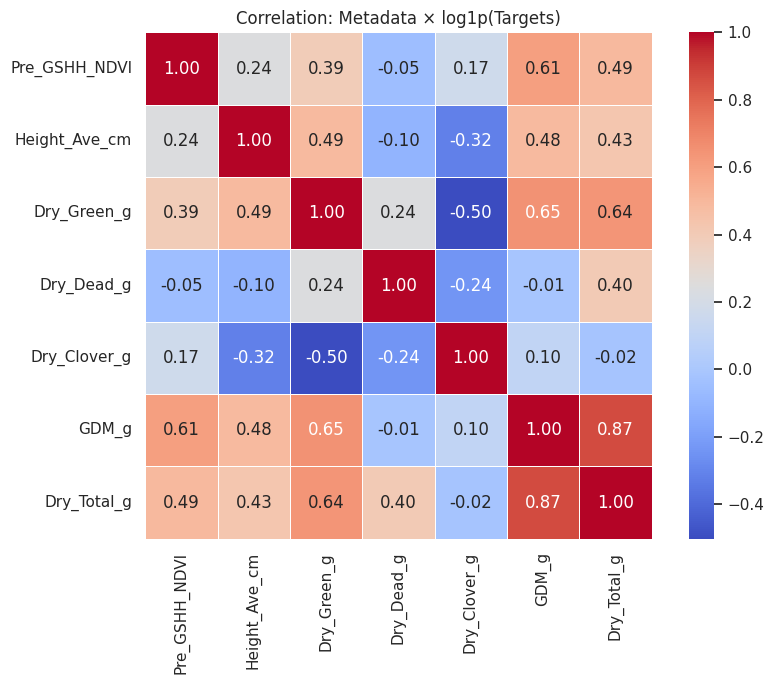

In [ ]:
# Correlation: metadata features vs targets (log1p)
numeric_cols = ["Pre_GSHH_NDVI", "Height_Ave_cm"] + TARGETS
corr = wide[numeric_cols].copy()
corr[TARGETS] = corr[TARGETS].apply(np.log1p)

plt.figure(figsize=(9, 7))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            square=True, linewidths=0.5)
plt.title("Correlation: Metadata × log1p(Targets)")
plt.tight_layout()
plt.show()



- **`Pre_GSHH_NDVI` → `GDM_g`: 0.61**, the strongest metadata-to-target correlation. NDVI is a greenness index, so it naturally correlates most with green dry matter. This is also the second most important competition target.
- **`Pre_GSHH_NDVI` → `Dry_Total_g`: 0.49**, meaningful but not dominant. NDVI captures live vegetation well but misses dead material.
- **`Height_Ave_cm` → `Dry_Green_g`: 0.49**, taller grass generally means more green biomass. This confirms that canopy height is an informative proxy.
- **`Dry_Clover_g` has negative correlations with most other targets** (-0.50 with `Dry_Green_g`, -0.32 with `Height_Ave_cm`). This makes biological sense: clover tends to grow in shorter, mixed pastures where grass is less dominant.
- **`Dry_Dead_g` is almost uncorrelated with NDVI (-0.05)**, dead material reflects very differently from live vegetation, so NDVI (which measures live greenness) is blind to it. This means the model will need to learn visual texture/color cues specific to dead material from the images.
- **`GDM_g` and `Dry_Total_g` are correlated at 0.87**, confirming that green matter dominates total biomass in this dataset.

## 6. Image Statistics


Before feeding images into a model, we need to know their dimensions (to plan resizing), whether any are corrupted, and what the typical pixel value range looks like. The channel mean and standard deviation are also needed for **normalization**, almost all pretrained vision backbones (ResNet, ViT, EfficientNet, etc.) expect inputs normalized using the dataset's own statistics or ImageNet's statistics (mean ≈ [0.485, 0.456, 0.406], std ≈ [0.229, 0.224, 0.225]).

Corrupt: 0  |  Unique sizes: {(2000, 1000)}


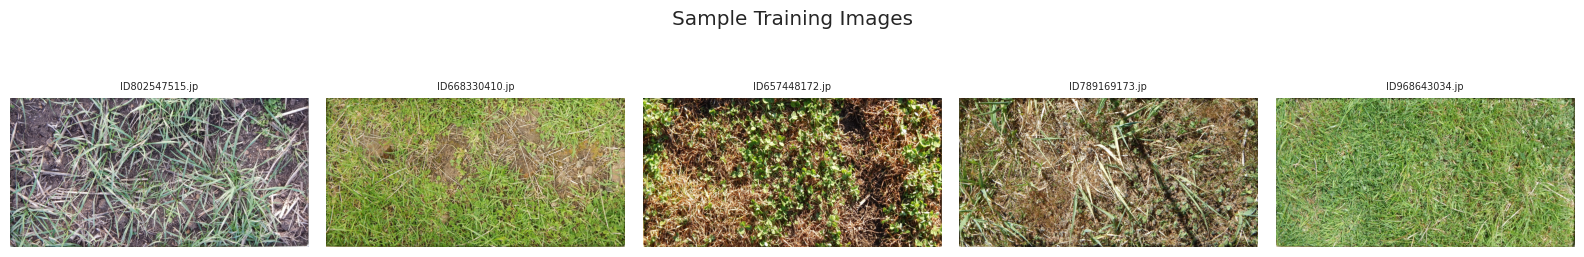

In [ ]:
from PIL import Image

corrupt, sizes = [], []
sample_imgs = []

for fname in os.listdir(TRAIN_IMGS)[:20]:
    fpath = os.path.join(TRAIN_IMGS, fname)
    try:
        img = Image.open(fpath)
        img.verify()
        sizes.append(img.size)
        sample_imgs.append(fpath)
    except Exception as e:
        corrupt.append((fname, str(e)))

print(f"Corrupt: {len(corrupt)}  |  Unique sizes: {set(sizes)}")

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, p in zip(axes, sample_imgs[:5]):
    ax.imshow(Image.open(p))
    ax.set_title(os.path.basename(p)[:14], fontsize=7)
    ax.axis("off")
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()



- **Corrupt: 0**: all images are valid JPEGs. No filtering needed.
- **Unique sizes: {(2000, 1000)}**:  all images are exactly 2000×1000 pixels (width × height). This is a consistent, standardized dataset, no mixed resolutions to handle.
- **Visual inspection** confirms the images are ground-level close-up shots of pasture. They show the kind of variation we need the model to learn: sparse vs. dense coverage, green vs. dead material, clover presence, bare soil patches. The images are visually distinct enough that a CNN backbone should be able to extract meaningful features.
- **Resizing note:** 2000×1000 is far too large for most backbones. Standard input sizes are 224×224 (lightweight models) or 384×384 (higher-accuracy models like ViT). We'll need to resize during the data loading step.

Channel means:
R    0.4659
G    0.5006
B    0.3166
dtype: float64

Channel stds:
R    0.0743
G    0.0612
B    0.0826
dtype: float64


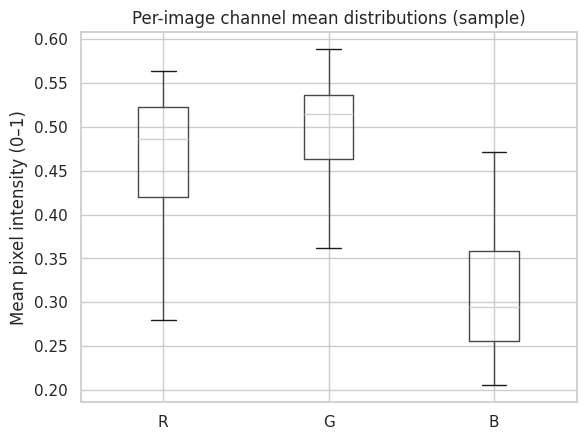

In [ ]:
channel_stats = {"R": [], "G": [], "B": []}

for p in sample_imgs:
    arr = np.array(Image.open(p).resize((224, 224))) / 255.0
    channel_stats["R"].append(arr[:,:,0].mean())
    channel_stats["G"].append(arr[:,:,1].mean())
    channel_stats["B"].append(arr[:,:,2].mean())

ch_df = pd.DataFrame(channel_stats)
print("Channel means:")
print(ch_df.mean().round(4))
print("\nChannel stds:")
print(ch_df.std().round(4))

ch_df.boxplot()
plt.title("Per-image channel mean distributions (sample)")
plt.ylabel("Mean pixel intensity (0–1)")
plt.show()



- **Channel means: R=0.466, G=0.501, B=0.317.** The green channel is the brightest on average, which makes sense, we're photographing grass. Blue is significantly darker, which is expected for outdoor ground-level photography.
- **Channel stds: R=0.074, G=0.061, B=0.083.** The variability is moderate and consistent across channels. The Blue channel has slightly more image-to-image variability, likely driven by the proportion of bare soil (which is reddish-brown, i.e., low blue).
- **Comparison to ImageNet normalization** (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]): our dataset has a higher green channel mean and lower blue mean than ImageNet. If using a pretrained backbone, it's worth experimenting with both ImageNet stats and dataset-specific stats for normalization.
- **Boxplot:** The spread across images is relatively tight (no extreme outliers), meaning image brightness is fairly consistent. This reduces the risk of lighting-based artifacts dominating the model's predictions.

## 7. Competition Metric Helper


We implement the exact competition scoring function locally so we can evaluate any model during development without submitting to Kaggle. We also run it on the simplest possible baseline, predicting the global mean for every image to get a floor score. Any model we train must beat this baseline to be considered useful.

In [ ]:
def weighted_log_r2(y_true_df, y_pred_df):
    """Compute the competition metric locally.

    Args:
        y_true_df, y_pred_df: DataFrames with columns = TARGETS
    Returns:
        (overall_score, per_target_dict)
    """
    scores = {}
    total  = 0.0
    for tgt in TARGETS:
        yt = np.log1p(y_true_df[tgt].values)
        yp = np.log1p(np.clip(y_pred_df[tgt].values, 0, None))
        s  = r2_score(yt, yp)
        scores[tgt] = round(s, 4)
        total += WEIGHTS[tgt] * s
    return round(total, 4), scores

# Naive baseline: predict global mean per target
y_true = wide[TARGETS].copy()
y_pred_mean = pd.DataFrame(
    {t: np.full(len(wide), wide[t].mean()) for t in TARGETS}
)

score, per_target = weighted_log_r2(y_true, y_pred_mean)
print(f"Mean-baseline weighted log-R²: {score}")
print("Per-target R²:")
for k, v in per_target.items():
    print(f"  {k} (w={WEIGHTS[k]}): {v}")

Mean-baseline weighted log-R²: -0.1506
Per-target R²:
  Dry_Green_g (w=0.1): -0.1863
  Dry_Dead_g (w=0.1): -0.2002
  Dry_Clover_g (w=0.1): -0.4784
  GDM_g (w=0.2): -0.1166
  Dry_Total_g (w=0.5): -0.0816


### Output interpretation

- **Mean-baseline weighted log-R²: -0.1506.** The mean-prediction baseline scores *below zero*. An R² of 0 means "no better than predicting the mean", so a negative R² means the metric is penalizing us even for the constant-mean prediction. This happens because R² is being computed on `log1p` values and the mean we're predicting is the mean of the *raw* values, not the log-transformed values, the two are not equivalent. This is a known subtlety of applying R² after a nonlinear transform.
- **Per-target breakdown:** `Dry_Clover_g` scores worst (-0.4784), consistent with its zero-inflation making even a mean prediction very inaccurate in log space. `Dry_Total_g` scores best (-0.0816), the most important target is also the most well-behaved and the easiest to get righT.